In [9]:
#KHỞI TẠO VÀ CẤU HÌNH CƠ BẢN (Imports & Global Config)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datascience import *
from scipy.stats import *
import warnings

df = pd.read_csv('bestsellers with categories - Data Science Project main.csv')
df_clean = df.copy()

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14

EXACT_COLUMNS = ["Name", "Author", "User Rating", "Reviews", "Price", "Year", "Genre"]

In [2]:
numeric_cols = ['User Rating', 'Reviews', 'Price', 'Year']

print("\n=== TỔNG QUAN DỮ LIỆU ===")
thong_ke_tong_quan = df_clean[numeric_cols].describe().T
thong_ke_tong_quan['Do_lech_(skew)'] = df_clean[numeric_cols].skew()
thong_ke_tong_quan['Do_nhon_(kurtosis)'] = df_clean[numeric_cols].apply(lambda x: x.kurtosis())
thong_ke_tong_quan


=== TỔNG QUAN DỮ LIỆU ===


,count,mean,std,min,25%,50%,75%,max,Do_lech_(skew),Do_nhon_(kurtosis)
User Rating,550.0,4.618364,0.226980,3.3,4.5,4.7,4.80,4.9,-1.502125,3.465375
Reviews,550.0,11953.281818,11731.132017,37.0,4058.0,8580.0,17253.25,87841.0,2.421597,8.809313
Price,550.0,13.100000,10.842262,0.0,7.0,11.0,16.00,105.0,3.685057,22.433520
Year,550.0,2014.000000,3.165156,2009.0,2011.0,2014.0,2017.00,2019.0,0.000000,-1.220175


In [3]:
print("\n=== Phân tích Tương quan ===")
# Tính ma trận tương quan Pearson giữa các cột số
ma_tran_tuong_quan = df_clean[numeric_cols].corr(method='pearson')
print("-> Ma trận tương quan:\n")
ma_tran_tuong_quan



=== Phân tích Tương quan ===
-> Ma trận tương quan:



,User Rating,Reviews,Price,Year
User Rating,1.000000,-0.001729,-0.133086,0.242383
Reviews,-0.001729,1.000000,-0.109182,0.263560
Price,-0.133086,-0.109182,1.000000,-0.153979
Year,0.242383,0.263560,-0.153979,1.000000


In [4]:
print("\n===Vai trò của Thể loại sách ===")
# Đếm số lượng thể loại và tìm ra thể loại xuất hiện nhiều nhất
so_the_loai = df_clean['Genre'].nunique()
the_loai_pho_bien_nhat = df_clean['Genre'].value_counts().idxmax()
print(f"-> Tổng số thể loại trong danh sách: {so_the_loai}")
print(f"-> Thể loại xuất hiện nhiều nhất (Thống trị danh sách): {the_loai_pho_bien_nhat}")

# So sánh Giá, Đánh giá, Lượng Review trung bình giữa các thể loại
print("\n-> So sánh các chỉ số trung bình giữa các Thể loại:\n")
df_clean.groupby('Genre')[numeric_cols].mean()



===Vai trò của Thể loại sách ===
-> Tổng số thể loại trong danh sách: 2
-> Thể loại xuất hiện nhiều nhất (Thống trị danh sách): Non Fiction

-> So sánh các chỉ số trung bình giữa các Thể loại:



,User Rating,Reviews,Price,Year
Genre,,,,
Fiction,4.648333,15683.791667,10.850000,2013.925000
Non Fiction,4.595161,9065.145161,14.841935,2014.058065


In [5]:
print("\n===Xu hướng thay đổi qua từng năm ===")
# Phân tích sự thay đổi của Giá, Đánh giá và Lượng Review qua từng năm
print("-> Xu hướng trung bình qua các năm:\n")
xu_huong_theo_nam = df_clean.groupby('Year')[numeric_cols].mean()
xu_huong_theo_nam


===Xu hướng thay đổi qua từng năm ===
-> Xu hướng trung bình qua các năm:



,User Rating,Reviews,Price,Year
Year,,,,
2009,4.584,4710.12,15.40,2009.0
2010,4.558,5479.62,13.48,2010.0
2011,4.558,8100.82,15.10,2011.0
2012,4.532,13090.92,15.30,2012.0
2013,4.554,13098.14,14.60,2013.0
2014,4.622,15859.94,14.64,2014.0
2015,4.648,14233.38,10.42,2015.0
2016,4.678,14196.00,13.18,2016.0
2017,4.660,12888.40,11.38,2017.0


In [6]:
# =============================================================================
#TRỰC QUAN HÓA DỮ LIỆU (TỔNG HỢP CÁC HÀM VẼ BIỂU ĐỒ)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

def plot_histogram(data, column, bins=20, title=None, color="skyblue"):
    """Vẽ biểu đồ phân phối (Histogram) cho 1 cột dữ liệu số"""
    plt.figure(figsize=(8, 6))
    sns.histplot(data=data, x=column, bins=bins, kde=True, color=color)
    plt.title(title if title else f"Phân phối của {column}", fontsize=14)
    plt.xlabel(column)
    plt.ylabel("Tần suất")
    plt.tight_layout()
    plt.show()

def plot_scatter(data, x_col, y_col, hue_col=None, title=None):
    """Vẽ biểu đồ phân tán (Scatter/Dot plot) để xem mối quan hệ giữa 2 biến số"""
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x=x_col, y=y_col, hue=hue_col, alpha=0.7)
    plt.title(title if title else f"Mối quan hệ giữa {x_col} và {y_col}", fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    if hue_col:
        plt.legend(title=hue_col)
    plt.tight_layout()
    plt.show()

def plot_bar(data, x_col, y_col, estimator='mean', title=None, color="salmon"):
    """Vẽ biểu đồ cột (Bar plot) để so sánh giá trị trung bình giữa các nhóm"""
    plt.figure(figsize=(10, 6))
    sns.barplot(data=data, x=x_col, y=y_col, errorbar=None, estimator=estimator, color=color)
    plt.title(title if title else f"Trung bình {y_col} theo {x_col}", fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_box(data, x_col, y_col, title=None):
    """Vẽ biểu đồ hộp (Box plot) để xem phân phối và ngoại lệ (outliers) của các nhóm"""
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x=x_col, y=y_col)
    plt.title(title if title else f"Phân phối {y_col} theo {x_col}", fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_line(data, x_col, y_col, hue_col=None, title=None):
    """Vẽ biểu đồ đường (Line plot) để xem xu hướng qua thời gian"""
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=data, x=x_col, y=y_col, hue=hue_col, marker="o", errorbar=None)
    plt.title(title if title else f"Xu hướng của {y_col} theo {x_col}", fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(data[x_col].unique()) # Hiển thị rõ các năm dưới trục x
    if hue_col:
        plt.legend(title=hue_col)
    plt.tight_layout()
    plt.show()

def plot_countplot(data, column, title=None, palette="Set2"):
    """Vẽ biểu đồ đếm số lượng cho các nhóm (categorical)"""
    plt.figure(figsize=(8, 6))
    sns.countplot(data=data, x=column, palette=palette)
    plt.title(title if title else f"Số lượng sách theo {column}", fontsize=14)
    plt.xlabel(column)
    plt.ylabel("Số lượng")

    # Thêm con số trên đầu mỗi cột cho rõ ràng
    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_pairplot(data, numeric_cols, hue_col=None):
    """Vẽ lưới biểu đồ (Pairplot) tổng quan toàn bộ biến số"""
    # Lọc lấy các cột số + cột hue (nếu có)
    cols_to_plot = numeric_cols + ([hue_col] if hue_col else [])
    sns.pairplot(data[cols_to_plot], hue=hue_col, corner=True, palette='husl')
    # corner=True để bỏ đi nửa trên bị trùng lặp của lưới
    plt.show()


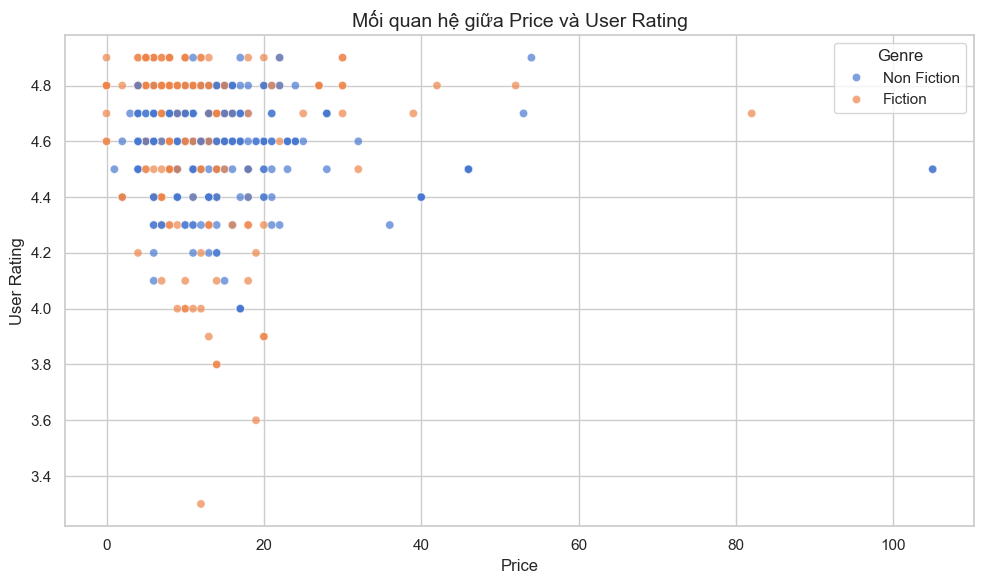

In [7]:
#plot_histogram(df_clean, column='Price', bins=30, title="Phân phối giá sách (Price)")

plot_scatter(df_clean, x_col='Price', y_col='User Rating', hue_col='Genre')

#plot_bar(df_clean, x_col='Genre', y_col='Reviews', title="Lượng đánh giá trung bình theo Thể loại")

#plot_box(df_clean, x_col='Genre', y_col='Price')

#plot_line(df_clean, x_col='Year', y_col='Price', hue_col='Genre')

#plot_countplot(df_clean, column='Genre')

#plot_pairplot(df_clean, numeric_cols, hue_col='Genre')


=== PHÂN TÍCH CHUYÊN SÂU: PRICING STRATEGIES VS USER SATISFACTION ===
-> Thống kê Đánh giá theo phân khúc giá:



,Pricing_Strategy,Average_Rating,Total_Books
0,Budget (≤$8),4.686500,200
1,Standard ($9-$15),4.593750,208
2,High ($16-$30),4.562931,116
3,Premium (>$30),4.538462,26



1. Biểu đồ phân tán (Scatter Plot): Mức độ phân tán giữa mức giá cụ thể và rating


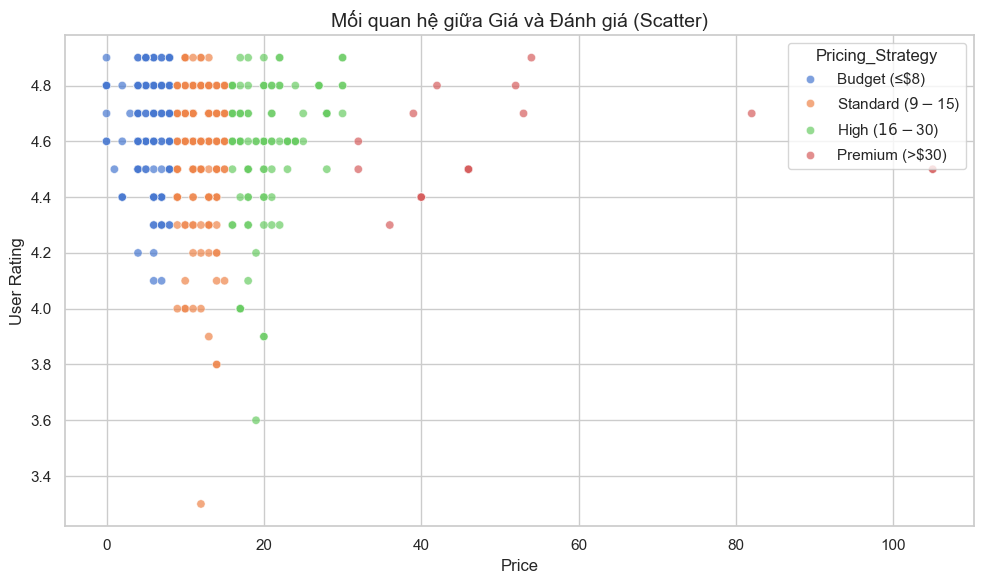


2. Biểu đồ hộp (Box Plot): Xem xét phân bố và các giá trị ngoại lệ (outliers) của từng phân khúc


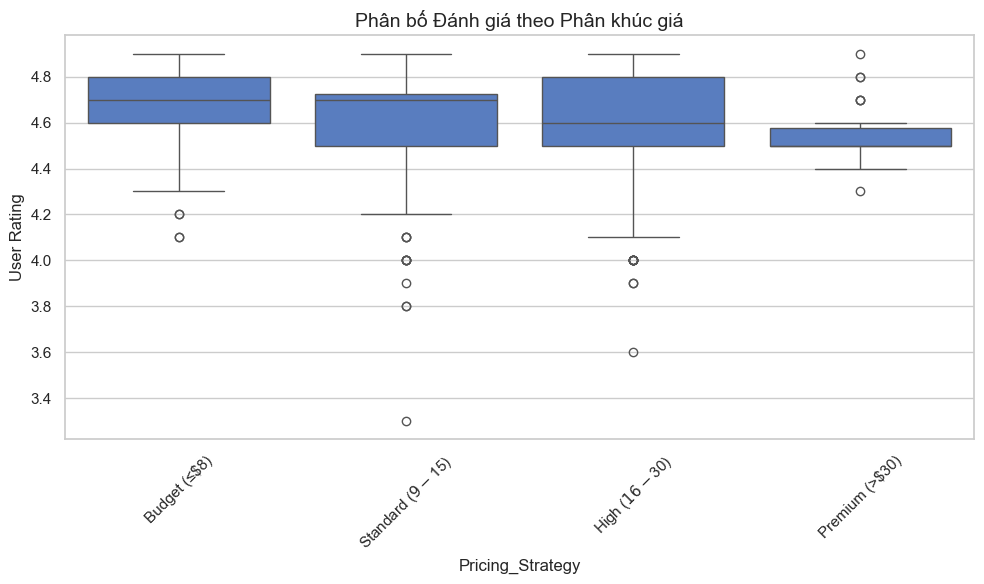


3. Biểu đồ cột (Bar Plot): So sánh điểm trung bình giữa các phân khúc (chú ý cột sẽ khá đều nhau vì rating trung bình luôn cao)


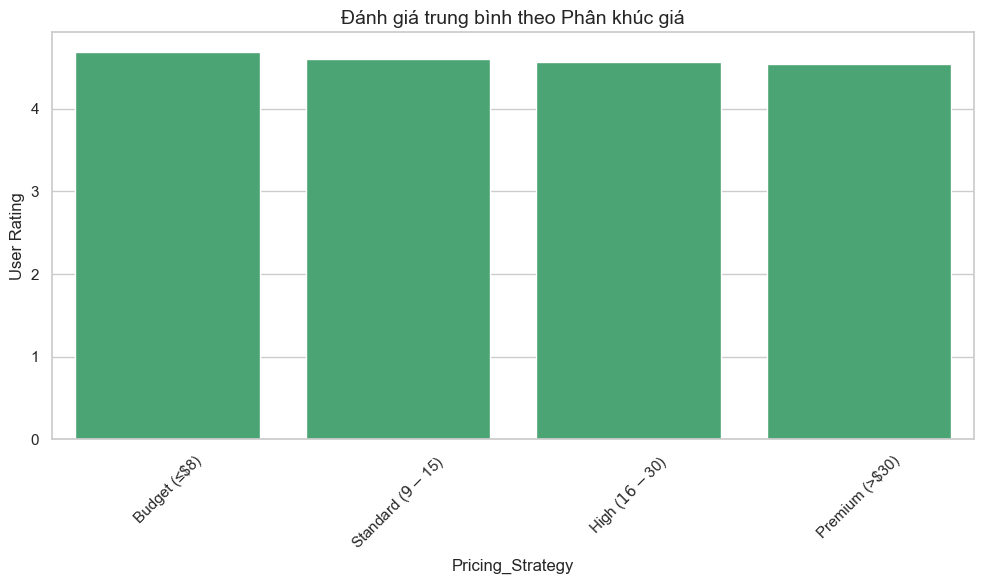

In [8]:
print("\n=== PHÂN TÍCH CHUYÊN SÂU: PRICING STRATEGIES VS USER SATISFACTION ===")

# 1. Phân loại chiến lược giá (Pricing Strategy/Tiers)
bins = [-1, 8, 15, 30, df_clean['Price'].max()]
labels = ['Budget (≤$8)', 'Standard ($9-$15)', 'High ($16-$30)', 'Premium (>$30)']
df_clean['Pricing_Strategy'] = pd.cut(df_clean['Price'], bins=bins, labels=labels)

# 2. Thống kê Đánh giá theo phân khúc giá
rating_by_price = df_clean.groupby('Pricing_Strategy').agg(
    Average_Rating=('User Rating', 'mean'),
    Total_Books=('Name', 'count')
).reset_index()

print("-> Thống kê Đánh giá theo phân khúc giá:\n")
display(rating_by_price)

print("\n1. Biểu đồ phân tán (Scatter Plot): Mức độ phân tán giữa mức giá cụ thể và rating")
plot_scatter(df_clean, x_col='Price', y_col='User Rating', hue_col='Pricing_Strategy', title='Mối quan hệ giữa Giá và Đánh giá (Scatter)')

print("\n2. Biểu đồ hộp (Box Plot): Xem xét phân bố và các giá trị ngoại lệ (outliers) của từng phân khúc")
plot_box(df_clean, x_col='Pricing_Strategy', y_col='User Rating', title='Phân bố Đánh giá theo Phân khúc giá')

print("\n3. Biểu đồ cột (Bar Plot): So sánh điểm trung bình giữa các phân khúc (chú ý cột sẽ khá đều nhau vì rating trung bình luôn cao)")
plot_bar(df_clean, x_col='Pricing_Strategy', y_col='User Rating', title='Đánh giá trung bình theo Phân khúc giá', color='mediumseagreen')

### Trả lời câu hỏi: Mối quan hệ giữa Chiến lược giá (Pricing Strategies) và Mức độ hài lòng (User Ratings)

Hệ số tương quan Pearson giữa `Price` và `User Rating` là **-0.133**, cho thấy mức độ tương quan nghịch rất yếu (gần như không có). Để nhìn rõ hơn về chiến lược giá, ta chia `Price` thành 4 phân khúc (Tiers): Budget (≤$8), Standard ($9-$15), High ($16-$30), và Premium (>$30).

**Kết luận:**
* Mức độ hài lòng (User Rating) gần như đồng đều và duy trì ở mức rất cao (~4.6 điểm) ở tất cả các phân khúc giá.
* Khách hàng mua sách Premium (>$30) có sự kỳ vọng rất cao, do đó phổ điểm đánh giá của nhóm này rộng hơn và dễ xuất hiện các ngoại lệ (outliers) đánh giá thấp nếu sách không đáp ứng kỳ vọng.
* Chiến lược giá rẻ (Budget) thu hút lượng lớn sách và dễ nhận được các đánh giá cao do rào cản kỳ vọng thấp.